# Part I: Two Stream Model Construction


Read CSV Files and Build Model Parameters


In this first step, I read the input CSV files and convert them into the wavelength-dependent parameters needed by the two-stream radiative transfer model. The model is spectrally resolved, meaning that every calculation is done wavelength by wavelength.

For each wavelength, the model needs:

$$
\lambda
$$

$$
\tau(\lambda)
$$

$$
\tilde{\omega}(\lambda)
$$

$$
g(\lambda)
$$

$$
r_s(\lambda)
$$

$$
F_0(\lambda)
$$


Since the the model calculations require every variable to be defined on the same wavelength grid, I interpolate the solar flux onto the model wavelength grid.

The aerosol extinction coefficient in the CSV file is normalized to one at:

$$
\lambda = 0.55 \ \mu m
$$

or:

$$
550 \ nm
$$

This means:

$$
B_e(0.55) = 1
$$

The value of $B_e(\lambda)$ at every other wavelength tells us the extinction relative to the extinction at $0.55 \ \mu m$. The homework gives the aerosol optical depth at $0.55 \ \mu m$:

$$
\tau_{a,0.55} = 1.0
$$

The aerosol optical depth at each wavelength is therefore:

$$
\tau_a(\lambda) = \tau_{a,0.55} B_e(\lambda)
$$

Since:

$$
\tau_{a,0.55} = 1.0
$$

then:

$$
\tau_a(\lambda) = B_e(\lambda)
$$

The Rayleigh layer is treated differently from the aerosol layer. For Rayleigh scattering, the homework gives the reference optical depth:

$$
\tau_{R,0.55} = 0.1
$$

Rayleigh scattering has a strong wavelength dependence. It is much stronger at shorter wavelengths and much weaker at longer wavelengths. Based on the rayleigh scattering cross section:

$$
\tau_R(\lambda) =
\tau_{R,0.55}
\left(
\frac{0.55}{\lambda}
\right)^4
$$



In [1]:
################################Read the csv files and create the necessary parameters###############################
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#upload the data
aerosol_file = "aerosol_properties.csv"
ocean_file = "ocean_reflectance.csv"
solar_file = "Fo.csv"

#Define the wavelength range
dlambda = 0.1 #um
wavelength = np.arange(0.4, 4 + dlambda, dlambda)

#reference optical depth values for the aerosol and rayleigh scattering at 0.55 um
tau_a_055 = 1.0
tau_R_055 = 0.1


# Read aerosol properties
aer = pd.read_csv(aerosol_file)

lambda_aer = aer["lambda (mu)"].values

# Dust aerosol properties
dust_Be = aer["dust Be"].values
dust_g = aer["dust g"].values
dust_omega = aer["dust omega"].values

# Pollution aerosol properties
poll_Be = aer["pollution Be"].values
poll_g = aer["pollution g"].values
poll_omega = aer["pollution omega"].values



# Read ocean surface reflectance
ocean = pd.read_csv(ocean_file)

lambda_ocean = ocean["lambda (mu)"].values
ocean_reflectance = ocean["reflectance"].values



# Read top-of-atmosphere solar flux
Fo = pd.read_csv(solar_file)

lambda_Fo_nm = Fo["lambda (nm)"].values
Fo_per_nm = Fo[" TOA Flux (W/m2/nm)"].values

# Convert wavelength from nm to microns
lambda_Fo_um = lambda_Fo_nm / 1000.0

# Convert flux from W/m2/nm to W/m2/um
# because 1 um = 1000 nm
Fo_per_um = Fo_per_nm * 1000.0

# Interpolate solar flux to match the 0.1 wavelength grid
F0_i = np.interp(wavelength, lambda_Fo_um, Fo_per_um)


# Aerosol optical depth spectra
tau_dust = tau_a_055 * dust_Be
tau_poll = tau_a_055 * poll_Be


# Rayleigh scattering layer
tau_R = tau_R_055 * (0.55 / wavelength)**4

# Rayleigh scattering is nearly nonabsorbing and approximately symmetric
omega_R = np.full_like(wavelength, 0.95)
g_R = np.zeros_like(wavelength)



# Model development for reflectance and transmittance of a layer in the atmosphere


The purpose of the two_stream_atmospheric_layer() function is to calculate the **reflectance** and **transmittance** of one atmospheric layer using the two-stream solution. For a specific atmospheric layer, the function takes three wavelength-dependent optical properties:

$$
\tau^*(\lambda)
$$

$$
\tilde{\omega}(\lambda)
$$

$$
g(\lambda)
$$


The function returns:

$$
r(\lambda)
$$

and

$$
t(\lambda)
$$


From the notes, we have:

$$
s_1 =
\sqrt{1-\tilde{\omega}g}
$$

and:

$$
s_2 =
\sqrt{1-\tilde{\omega}}
$$

$$
\Gamma = 2s_1s_2
$$

$$
r_\infty =
\frac{s_1 - s_2}{s_1 + s_2}
$$


For a layer with finite optical depth $\tau^*$, the notes give the layer reflectance as:

$$
r =
\frac{
r_\infty
\left(
e^{\Gamma \tau^*}
-
e^{-\Gamma \tau^*}
\right)
}{
e^{\Gamma \tau^*}
-
r_\infty^2 e^{-\Gamma \tau^*}
}
$$

The layer transmittance is:

$$
t =
\frac{
1-r_\infty^2
}{
e^{\Gamma \tau^*}
-
r_\infty^2 e^{-\Gamma \tau^*}
}
$$


In [2]:
def two_stream_atmospheric_layer(tau, omega, g):

    tau = np.asarray(tau, dtype=float)
    omega = np.asarray(omega, dtype=float)
    g = np.asarray(g, dtype=float)

    r = np.zeros_like(tau)
    t = np.zeros_like(tau)


    s1 = np.sqrt(1.0 - omega * g)
    s2 = np.sqrt(1.0 - omega)

    Gamma = 2.0 * s1 * s2

    r_inf = (s1 - s2) / (s1 + s2)

    exp_positive = np.exp(Gamma * tau)
    exp_negative = np.exp(-Gamma * tau)

    denom = exp_positive - r_inf**2 * exp_negative

    r = r_inf * (exp_positive - exp_negative) / denom
    t = (1.0 - r_inf**2) / denom

    return r, t

After calculating the reflectance and transmittance of each individual atmospheric layer, I need to combine them into one effective atmospheric layer. In this model, the atmosphere has two scattering layers:

Aerosol layer
Rayleigh layer

The homework specifies that the Rayleigh scattering layer is below the aerosol layer, so the vertical order is:


Top of atmosphere
Aerosol layer
Rayleigh layer
Surface


For each layer, the two-stream function gives:

$$
r_1(\lambda), \ t_1(\lambda)
$$

for the upper layer, and:

$$
r_2(\lambda), \ t_2(\lambda)
$$

for the lower layer.

In this assignment:

$$
r_1 = r_{aer}
$$

$$
t_1 = t_{aer}
$$

$$
r_2 = r_R
$$

$$
t_2 = t_R
$$

The goal is to calculate the combined atmospheric reflectance and transmittance:

$$
r_{atm}(\lambda)
$$

and:

$$
t_{atm}(\lambda)
$$


The combined reflectance of the two layers is:

$$
\boxed{
r_{atm}
=
r_{aer}
+
\frac{t_{aer}^2 r_R}{1-r_{aer}r_R}
}
$$


and the combined transmittance of the two layers is:

$$
\boxed{
t_{atm}
=
\frac{t_{aer}t_R}{1-r_{aer}r_R}
}
$$

In [3]:
def combine_two_atmospheric_layers(r1, t1, r2, t2):

    denom = 1.0 - r1 * r2

    r12 = r1 + (t1**2 * r2) / denom
    t12 = (t1 * t2) / denom

    return r12, t12

Now, we add the surface terms into our equations to get the scene reflectance and transmittance:

In [21]:
def two_stream_model_with_surface(r_atm, t_atm, r_sfc):

    denom = 1.0 - r_sfc * r_atm

    r_scene = r_atm + (t_atm**2 * r_sfc) / denom
    t_scene = t_atm / denom

    return r_scene, t_scene

And finally, I use the parameters from csv files as input for my model and calculate the results:

In [23]:
#calculate the reflectance and transmittance of the aerosol layer and the rayleigh scattering layer
r_aer, t_aer = two_stream_atmospheric_layer(tau_dust, dust_omega, dust_g)
r_R, t_R = two_stream_atmospheric_layer(tau_R, omega_R, g_R)

#Calculate the reflectance and transmittance of the combined atmospheric layer (aerosol + rayleigh)
r_atm, t_atm = combine_two_atmospheric_layers(r_aer, t_aer, r_R, t_R)

#Calculate the reflectance and transmittance of the entire scene (atmosphere + ocean surface)
r_scene, t_scene = two_stream_model_with_surface(r_atm, t_atm, ocean_reflectance)

scene_table = pd.DataFrame({
    "wavelength (um)": wavelength,
    "r_aer": r_aer,
    "t_aer": t_aer,
    "r_R": r_R,
    "t_R": t_R,
    "r_atm": r_atm,
    "t_atm": t_atm,
    "r_scene": r_scene,
    "t_scene": t_scene
})

scene_table

,wavelength (um),r_aer,t_aer,r_R,t_R,r_atm,t_atm,r_scene,t_scene
0,0.4,0.258103,0.623427,0.245388,0.719568,0.359925,0.478931,0.406758,0.514127
1,0.5,0.232412,0.665597,0.120407,0.865063,0.287290,0.592360,0.324387,0.610352
2,0.6,0.203198,0.703767,0.062427,0.930537,0.234514,0.663296,0.260781,0.672583
3,0.7,0.176187,0.738724,0.034810,0.961386,0.195300,0.714582,0.220935,0.721588
4,0.8,0.155252,0.760288,0.020736,0.977032,0.167277,0.745225,0.193038,0.751008
5,0.9,0.142221,0.771043,0.013058,0.985548,0.149998,0.761314,0.166008,0.764468
6,1.0,0.125985,0.784719,0.008610,0.990475,0.131293,0.778088,0.149161,0.781103
7,1.1,0.106329,0.796369,0.005899,0.993476,0.110072,0.791671,0.126857,0.794004
8,1.2,0.092912,0.811641,0.004173,0.995386,0.095662,0.808209,0.113037,0.810266
9,1.3,0.083848,0.823077,0.003033,0.996646,0.085903,0.820525,0.101259,0.822133


# Verification 1

For the first test, I will change my surface to a black body with reflectance of zero. While this would change the scene reflectance and transmittance, it should not change the atmospheric reflectance and transmittance, which is only a function of the atmospheric layers. As a result, the scene reflectance and transmittance values should match those of atmosphere. The resulting table shows that the model passes this test.

In [24]:
#calculate the reflectance and transmittance of the aerosol layer and the rayleigh scattering layer
r_aer, t_aer = two_stream_atmospheric_layer(tau_dust, dust_omega, dust_g)
r_R, t_R = two_stream_atmospheric_layer(tau_R, omega_R, g_R)

#Calculate the reflectance and transmittance of the combined atmospheric layer (aerosol + rayleigh)
r_atm, t_atm = combine_two_atmospheric_layers(r_aer, t_aer, r_R, t_R)

#consider a black body surface with r=0
r_sfc = np.zeros_like(r_atm)
#Calculate the reflectance and transmittance of the entire scene (atmosphere + ocean surface)
r_scene, t_scene = two_stream_model_with_surface(r_atm, t_atm, r_sfc)

scene_table = pd.DataFrame({
    "wavelength (um)": wavelength,
    "r_aer": r_aer,
    "t_aer": t_aer,
    "r_R": r_R,
    "t_R": t_R,
    "r_atm": r_atm,
    "t_atm": t_atm,
    "r_scene": r_scene,
    "t_scene": t_scene
})

scene_table

,wavelength (um),r_aer,t_aer,r_R,t_R,r_atm,t_atm,r_scene,t_scene
0,0.4,0.258103,0.623427,0.245388,0.719568,0.359925,0.478931,0.359925,0.478931
1,0.5,0.232412,0.665597,0.120407,0.865063,0.287290,0.592360,0.287290,0.592360
2,0.6,0.203198,0.703767,0.062427,0.930537,0.234514,0.663296,0.234514,0.663296
3,0.7,0.176187,0.738724,0.034810,0.961386,0.195300,0.714582,0.195300,0.714582
4,0.8,0.155252,0.760288,0.020736,0.977032,0.167277,0.745225,0.167277,0.745225
5,0.9,0.142221,0.771043,0.013058,0.985548,0.149998,0.761314,0.149998,0.761314
6,1.0,0.125985,0.784719,0.008610,0.990475,0.131293,0.778088,0.131293,0.778088
7,1.1,0.106329,0.796369,0.005899,0.993476,0.110072,0.791671,0.110072,0.791671
8,1.2,0.092912,0.811641,0.004173,0.995386,0.095662,0.808209,0.095662,0.808209
9,1.3,0.083848,0.823077,0.003033,0.996646,0.085903,0.820525,0.085903,0.820525


# Verification 2

Here, I'll assume that my atmosphere has only one layer with an optical depth that is much smaller than 1. Considering the same black body surface as before and since or sky is transparent, most of our radiation should be transmitted to the surface and the surface reflectance should be near zero.

In [25]:
#calculate the reflectance and transmittance of the aerosol layer and the rayleigh scattering layer
#r_aer, t_aer = two_stream_atmospheric_layer(tau_dust, dust_omega, dust_g)
tau_thin = np.full_like(wavelength, 1e-8)
r_R, t_R = two_stream_atmospheric_layer(tau_thin, omega_R, g_R)

#Calculate the reflectance and transmittance of the combined atmospheric layer (aerosol + rayleigh)
#r_atm, t_atm = combine_two_atmospheric_layers(r_aer, t_aer, r_R, t_R)

#consider a black body surface with r=0
r_sfc = np.zeros_like(r_atm)
#Calculate the reflectance and transmittance of the entire scene (atmosphere + ocean surface)
r_scene, t_scene = two_stream_model_with_surface(r_R, t_R, r_sfc)

scene_table = pd.DataFrame({
    "wavelength (um)": wavelength,
    "r_R": r_R,
    "t_R": t_R,
    "r_scene": r_scene,
    "t_scene": t_scene
})

scene_table

,wavelength (um),r_R,t_R,r_scene,t_scene
0,0.4,9.500000e-09,1.0,9.500000e-09,1.0
1,0.5,9.500000e-09,1.0,9.500000e-09,1.0
2,0.6,9.500000e-09,1.0,9.500000e-09,1.0
3,0.7,9.500000e-09,1.0,9.500000e-09,1.0
4,0.8,9.500000e-09,1.0,9.500000e-09,1.0
5,0.9,9.500000e-09,1.0,9.500000e-09,1.0
6,1.0,9.500000e-09,1.0,9.500000e-09,1.0
7,1.1,9.500000e-09,1.0,9.500000e-09,1.0
8,1.2,9.500000e-09,1.0,9.500000e-09,1.0
9,1.3,9.500000e-09,1.0,9.500000e-09,1.0


# Question 5.3 

First, I'll run the model for both dust and pollution cases:

# Dust

In [26]:
#calculate the reflectance and transmittance of the aerosol layer and the rayleigh scattering layer
r_aer, t_aer = two_stream_atmospheric_layer(tau_dust, dust_omega, dust_g)
r_R, t_R = two_stream_atmospheric_layer(tau_R, omega_R, g_R)

#Calculate the reflectance and transmittance of the combined atmospheric layer (aerosol + rayleigh)
r_atm, t_atm = combine_two_atmospheric_layers(r_aer, t_aer, r_R, t_R)

#Calculate the reflectance and transmittance of the entire scene (atmosphere + ocean surface)
r_scene_dust, t_scene_dust = two_stream_model_with_surface(r_atm, t_atm, ocean_reflectance)

# Pollution

In [27]:
#calculate the reflectance and transmittance of the aerosol layer and the rayleigh scattering layer
r_aer, t_aer = two_stream_atmospheric_layer(tau_poll, poll_omega, poll_g)
r_R, t_R = two_stream_atmospheric_layer(tau_R, omega_R, g_R)

#Calculate the reflectance and transmittance of the combined atmospheric layer (aerosol + rayleigh)
r_atm, t_atm = combine_two_atmospheric_layers(r_aer, t_aer, r_R, t_R)

#Calculate the reflectance and transmittance of the entire scene (atmosphere + ocean surface)
r_scene_poll, t_scene_poll = two_stream_model_with_surface(r_atm, t_atm, ocean_reflectance)

scene_table = pd.DataFrame({
    "wavelength (um)": wavelength,
    "r_scene_dust": r_scene_dust,
    "t_scene_dust": t_scene_dust,
    "r_scene_pollution": r_scene_poll,
    "t_scene_pollution": t_scene_poll
})

scene_table

,wavelength (um),r_scene_dust,t_scene_dust,r_scene_pollution,t_scene_pollution
0,0.4,0.406758,0.514127,0.156111,0.275756
1,0.5,0.324387,0.610352,0.141050,0.376028
2,0.6,0.260781,0.672583,0.125785,0.460727
3,0.7,0.220935,0.721588,0.115057,0.522485
4,0.8,0.193038,0.751008,0.108080,0.560445
5,0.9,0.166008,0.764468,0.095593,0.586891
6,1.0,0.149161,0.781103,0.089443,0.613499
7,1.1,0.126857,0.794004,0.081860,0.642591
8,1.2,0.113037,0.810266,0.074433,0.676063
9,1.3,0.101259,0.822133,0.067987,0.688772


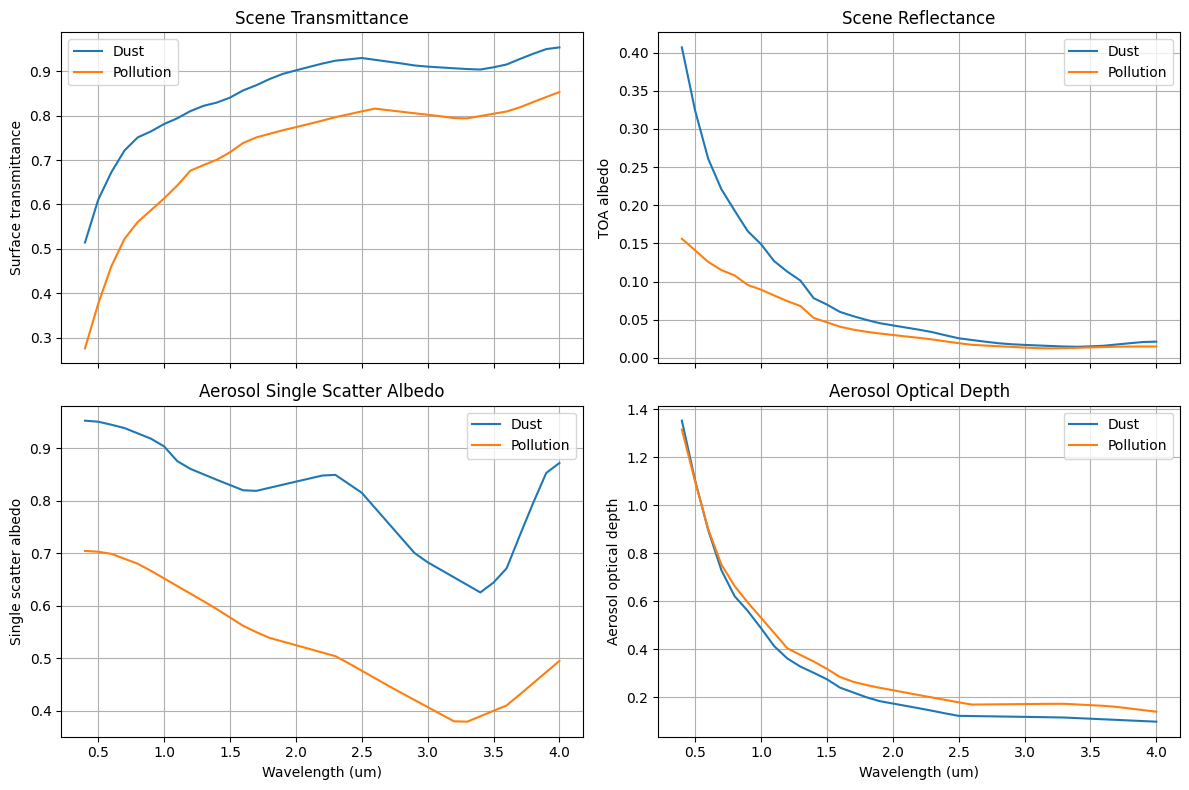

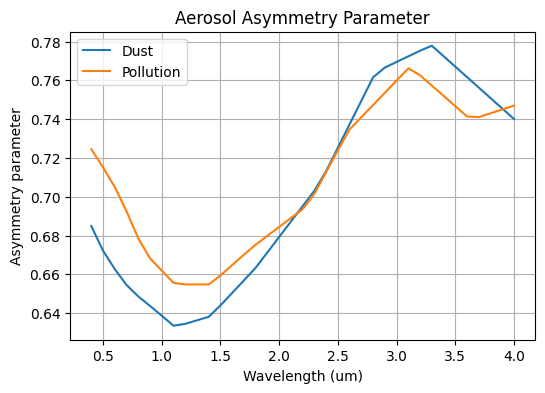

In [28]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

# --------------------------------------------------
# 1. Surface transmittance
# --------------------------------------------------
axs[0, 0].plot(wavelength, t_scene_dust, label="Dust")
axs[0, 0].plot(wavelength, t_scene_poll, label="Pollution")
axs[0, 0].set_ylabel("Surface transmittance")
axs[0, 0].set_title("Scene Transmittance")
axs[0, 0].legend()
axs[0, 0].grid(True)

# --------------------------------------------------
# 2. TOA albedo / reflectance
# --------------------------------------------------
axs[0, 1].plot(wavelength, r_scene_dust, label="Dust")
axs[0, 1].plot(wavelength, r_scene_poll, label="Pollution")
axs[0, 1].set_ylabel("TOA albedo")
axs[0, 1].set_title("Scene Reflectance")
axs[0, 1].legend()
axs[0, 1].grid(True)

# --------------------------------------------------
# 3. Single scatter albedo
# --------------------------------------------------
axs[1, 0].plot(wavelength, dust_omega, label="Dust")
axs[1, 0].plot(wavelength, poll_omega, label="Pollution")
axs[1, 0].set_xlabel("Wavelength (um)")
axs[1, 0].set_ylabel("Single scatter albedo")
axs[1, 0].set_title("Aerosol Single Scatter Albedo")
axs[1, 0].legend()
axs[1, 0].grid(True)

# --------------------------------------------------
# 4. Aerosol optical depth
# --------------------------------------------------
axs[1, 1].plot(wavelength, tau_dust, label="Dust")
axs[1, 1].plot(wavelength, tau_poll, label="Pollution")
axs[1, 1].set_xlabel("Wavelength (um)")
axs[1, 1].set_ylabel("Aerosol optical depth")
axs[1, 1].set_title("Aerosol Optical Depth")
axs[1, 1].legend()
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 5. Asymmetry parameter
# --------------------------------------------------
plt.figure(figsize=(6, 4))
plt.plot(wavelength, dust_g, label="Dust")
plt.plot(wavelength, poll_g, label="Pollution")
plt.xlabel("Wavelength (um)")
plt.ylabel("Asymmetry parameter")
plt.title("Aerosol Asymmetry Parameter")
plt.legend()
plt.grid(True)
plt.show()


The spectrally resolved surface transmittance and TOA albedo show that dust produces both higher scene transmittance and higher scene reflectance than pollution over most wavelengths. This behavior is consistent with the aerosol single scatter albedo, which is higher for dust and lower for pollution. This results in a more absorption in the pollution layer. Both aerosol types have their largest optical depths at short wavelengths, so their effects on radiation are strongest in the visible part of the spectrum. At these wavelengths, scene transmittance is lowest and scene reflectance is highest. As wavelength increases, aerosol optical depth decreases, so the atmosphere becomes more transparent and the scene reflectance decreases. The asymmetry parameters of the two aerosol types are relatively similar, with both aerosols having positive values, indicating mostly forward scattering. However, the dominant reason for the different transmittance and reflectance is the much lower single scatter albedo of pollution compared with dust.

# Part II: Shortwave Fluxes and the DRE

# Calculating Shortwave Fluxes and Net Fluxes

The model calculates fluxes at three levels:

Top of atmosphere
Atmosphere
Surface


The incoming solar flux at the top of the atmosphere is read from Fo.csv.

This is the spectral downwelling solar flux:

$$
F_0(\lambda)
$$

At the top of the atmosphere, the downwelling flux is:

$$
F^\downarrow_{TOA}(\lambda) = F_0(\lambda)
$$


The upward flux at the top of the atmosphere is determined by the total scene reflectance:

$$
r_{scene}(\lambda)
$$


Therefore, the upward flux at the top of the atmosphere is:

$$
F^\uparrow_{TOA}(\lambda)
=
r_{scene}(\lambda) F_0(\lambda)
$$


the net flux at the top of the atmosphere is:

$$
F_{N,TOA}(\lambda)
=
F_0(\lambda)
\left[
1-r_{scene}(\lambda)
\right]
$$


The downward flux at the surface is determined by the total scene transmittance:

$$
t_{scene}(\lambda)
$$

Therefore:

$$
F^\downarrow_{sfc}(\lambda)
=
t_{scene}(\lambda)F_0(\lambda)
$$


The surface reflects a fraction of the downward radiation. The homework defines the upward surface shortwave flux as:

$$
F^\uparrow_s = r_s F^\downarrow_s
$$

Therefore:

$$
F^\uparrow_{sfc}(\lambda)
=
r_s(\lambda)t_{scene}(\lambda)F_0(\lambda)
$$


The surface net flux is:

$$
F_{N,sfc}(\lambda)
=
t_{scene}(\lambda)F_0(\lambda)
\left[
1-r_s(\lambda)
\right]
$$

The atmosphere lies between the top of the atmosphere and the surface.

The homework gives the relationship:

$$
F^N_{TOA}
=
F^N_{sfc}
+
F^N_{atm}
$$

Therefore, the atmospheric net flux is:

$$
F^N_{atm}
=
F^N_{TOA}
-
F^N_{sfc}
$$

At each wavelength:

$$
F_{N,atm}(\lambda)
=
F_{N,TOA}(\lambda)
-
F_{N,sfc}(\lambda)
$$


# Calculating the Direct Radiative Effect (DRE)

The direct radiative effect is defined as:

$$
DRE = F_N - F_{N,p}
$$

Before calculating DRE, we need a pristine reference atmosphere:

$$
F^\downarrow_{TOA,p}(\lambda)
$$

$$
F^\uparrow_{TOA,p}(\lambda)
$$

$$
F^N_{TOA,p}(\lambda)
$$

$$
F^\downarrow_{sfc,p}(\lambda)
$$

$$
F^\uparrow_{sfc,p}(\lambda)
$$

$$
F^N_{sfc,p}(\lambda)
$$

and:

$$
F^N_{atm,p}(\lambda)
$$

At the top of the atmosphere, the incoming solar flux is the same for the pristine and aerosol cases:

$$
F^\downarrow_{TOA}(\lambda) =
F^\downarrow_{TOA,p}(\lambda)
=
F_0(\lambda)
$$

Therefore, the TOA DRE can be written using only the upward fluxes:

$$
DRE_{TOA}(\lambda)
=
F^N_{TOA}(\lambda)
-
F^N_{TOA,p}(\lambda)
$$

Using:

$$
F^N_{TOA} = F^\downarrow_{TOA} - F^\uparrow_{TOA}
$$

we get:

$$
DRE_{TOA}(\lambda)
=
\left[
F^\downarrow_{TOA}(\lambda)
-
F^\uparrow_{TOA}(\lambda)
\right]
-
\left[
F^\downarrow_{TOA,p}(\lambda)
-
F^\uparrow_{TOA,p}(\lambda)
\right]
$$

So:

$$
\boxed{
DRE_{TOA}(\lambda)
=
F^\uparrow_{TOA,p}(\lambda)
-
F^\uparrow_{TOA,aer}(\lambda)
}
$$

At the surface, the DRE is the difference between aerosol and pristine net surface flux:

$$
DRE_{sfc}(\lambda)
=
F^N_{sfc}(\lambda)
-
F^N_{sfc,p}(\lambda)
$$

The surface net flux is:

$$
F^N_{sfc}(\lambda)
=
F^\downarrow_{sfc}(\lambda)
-
F^\uparrow_{sfc}(\lambda)
$$

The homework assumes that the upward surface flux is related to the downward surface flux by:

$$
F^\uparrow_s(\lambda)
=
r_s(\lambda)F^\downarrow_s(\lambda)
$$

Therefore:

$$
F^N_{sfc}(\lambda)
=
F^\downarrow_{sfc}(\lambda)
-
r_s(\lambda)F^\downarrow_{sfc}(\lambda)
$$

Therefore, the surface DRE is:

$$
\boxed{
DRE_{sfc}(\lambda)
=
\left[
F^\downarrow_{sfc,aer}(\lambda)
-
F^\downarrow_{sfc,p}(\lambda)
\right]
\left[
1-r_s(\lambda)
\right]
}
$$


The net fluxes satisfy:

$$
F^N_{TOA}
=
F^N_{sfc}
+
F^N_{atm}
$$

Therefore:

$$
F^N_{atm}
=
F^N_{TOA}
-
F^N_{sfc}
$$

The atmospheric DRE is:

$$
\boxed{
DRE_{atm}
=
DRE_{TOA}
-
DRE_{sfc}
}
$$


In the following cells, I will write functions for the following calculations and simulations:

1. Computing net fluxes
2. Full two stream model based on part I to calculate the scene reflectance and transmittance for dust, pollution, and pristine cases.
3. Perform integral over all wavelengths for net fluxes.
4. Function to calculate the DRE for TOA, surface, and atmosphere.

In [ ]:
######################## 1. Calculate net fluxes at TOA, surface, and the atmosphere###############################
def compute_fluxes(r_scene, t_scene, r_sfc, F0):

    Fdown_TOA = F0
    Fup_TOA = r_scene * F0

    Fdown_sfc = t_scene * F0
    Fup_sfc = r_sfc * Fdown_sfc

    Fnet_TOA = Fdown_TOA - Fup_TOA
    Fnet_sfc = Fdown_sfc - Fup_sfc
    Fnet_atm = Fnet_TOA - Fnet_sfc

    flux = {
        "Fdown_TOA": Fdown_TOA,
        "Fup_TOA": Fup_TOA,
        "Fnet_TOA": Fnet_TOA,
        "Fdown_sfc": Fdown_sfc,
        "Fup_sfc": Fup_sfc,
        "Fnet_sfc": Fnet_sfc,
        "Fnet_atm": Fnet_atm,
    }

    return flux

def integrate_spectral(y, wavelength):
    return np.trapz(y, wavelength)

######################## 2. Calculate two stream model for dust, pollution, and pristine cases###############################
def full_two_stream_model(tau_aer, omega_aer, g_aer, case_name):


    # Aerosol layer
    r_aer, t_aer = two_stream_atmospheric_layer(tau_aer, omega_aer, g_aer)

    # Rayleigh layer
    r_ray, t_ray = two_stream_atmospheric_layer(tau_R, omega_R, g_R)

    # Combine aerosol layer over Rayleigh layer
    r_atm, t_atm = combine_two_atmospheric_layers(r_aer, t_aer, r_ray, t_ray)

    # Add ocean surface
    r_scene, t_scene = two_stream_model_with_surface(r_atm, t_atm, ocean_reflectance)

    # Compute spectral fluxes
    flux = compute_fluxes(r_scene, t_scene, ocean_reflectance, F0_i)

    result = {
        "case_name": case_name,
        "r_aer": r_aer,
        "t_aer": t_aer,
        "r_ray": r_ray,
        "t_ray": t_ray,
        "r_atm": r_atm,
        "t_atm": t_atm,
        "r_scene": r_scene,
        "t_scene": t_scene,
        "flux": flux,
    }

    return result

def run_pristine_case():

    # Rayleigh layer only
    r_ray, t_ray = two_stream_atmospheric_layer(tau_R, omega_R, g_R)

    r_atm = r_ray
    t_atm = t_ray

    # Add ocean surface
    r_scene, t_scene = two_stream_model_with_surface(r_atm, t_atm, ocean_reflectance)

    # Compute spectral fluxes
    flux = compute_fluxes(r_scene, t_scene, ocean_reflectance, F0_i)

    result = {
        "case_name": "pristine",
        "r_ray": r_ray,
        "t_ray": t_ray,
        "r_atm": r_atm,
        "t_atm": t_atm,
        "r_scene": r_scene,
        "t_scene": t_scene,
        "flux": flux,
    }

    return result

######################## 3. Integral over wavelength###############################
def broadband_flux_summary(result):

    flux = result["flux"]

    summary = {}

    for key, value in flux.items():
        summary[key] = integrate_spectral(value, wavelength)

    return summary


######################## 4. Calculate the TOA, surface, and the atmospheric DRE###############################
def compute_DRE(aerosol_result, pristine_result):

    aer_flux = aerosol_result["flux"]
    pri_flux = pristine_result["flux"]

    # Spectral TOA DRE
    # DRE_TOA = Fup_pristine - Fup_aerosol
    DRE_TOA_lambda = pri_flux["Fup_TOA"] - aer_flux["Fup_TOA"]

    # Spectral surface DRE
    # DRE_sfc = (Fdown_aerosol - Fdown_pristine) * (1 - rs)
    DRE_sfc_lambda = (
        aer_flux["Fdown_sfc"] - pri_flux["Fdown_sfc"]
    ) * (1.0 - ocean_reflectance)

    # Spectral atmospheric DRE
    DRE_atm_lambda = DRE_TOA_lambda - DRE_sfc_lambda

    # Broadband DRE
    DRE_TOA = integrate_spectral(DRE_TOA_lambda, wavelength)
    DRE_sfc = integrate_spectral(DRE_sfc_lambda, wavelength)
    DRE_atm = integrate_spectral(DRE_atm_lambda, wavelength)

    dre = {
        "DRE_TOA_lambda": DRE_TOA_lambda,
        "DRE_sfc_lambda": DRE_sfc_lambda,
        "DRE_atm_lambda": DRE_atm_lambda,
        "DRE_TOA": DRE_TOA,
        "DRE_sfc": DRE_sfc,
        "DRE_atm": DRE_atm,
    }

    return dre

# Verification

For validating the DRE calculations, I'm going to reduce the optical depth of my dust layer to a very small value. In this case, the net flux of atmosphere with dust should be very close to pristine atmosphere. As a result, the DRE values for dust case should be close to zero.

In [54]:
pristine = run_pristine_case()

dust = full_two_stream_model(
    tau_aer = np.full_like(wavelength, 1e-8),
    omega_aer=dust_omega,
    g_aer=dust_g,
    case_name="dust"
)

pollution = full_two_stream_model(
    tau_aer=tau_poll,
    omega_aer=poll_omega,
    g_aer=poll_g,
    case_name="pollution"
)

pristine_flux = broadband_flux_summary(pristine)
dust_flux = broadband_flux_summary(dust)
pollution_flux = broadband_flux_summary(pollution)

flux_table = pd.DataFrame(
    [pristine_flux, dust_flux, pollution_flux],
    index=["pristine", "dust", "pollution"]
)
display(flux_table)

dust_DRE = compute_DRE(dust, pristine)
pollution_DRE = compute_DRE(pollution, pristine)


DRE_table = pd.DataFrame(
    {
        "dust": {
            "DRE_TOA": dust_DRE["DRE_TOA"],
            "DRE_sfc": dust_DRE["DRE_sfc"],
            "DRE_atm": dust_DRE["DRE_atm"],
        },
        "pollution": {
            "DRE_TOA": pollution_DRE["DRE_TOA"],
            "DRE_sfc": pollution_DRE["DRE_sfc"],
            "DRE_atm": pollution_DRE["DRE_atm"],
        },
    }
)

display(DRE_table)


C:\Users\ehsan\AppData\Local\Temp\ipykernel_43196\2110050226.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(y, wavelength)


,Fdown_TOA,Fup_TOA,Fnet_TOA,Fdown_sfc,Fup_sfc,Fnet_sfc,Fnet_atm
pristine,1239.322141,117.427215,1121.894926,1172.356031,59.342920,1113.013111,8.881815
dust,1239.322141,117.427218,1121.894923,1172.356026,59.342919,1113.013106,8.881817
pollution,1239.322141,125.042321,1114.279820,677.023612,28.522557,648.501055,465.778764


C:\Users\ehsan\AppData\Local\Temp\ipykernel_43196\2110050226.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(y, wavelength)


,dust,pollution
DRE_TOA,-0.000003,-7.615107
DRE_sfc,-0.000005,-464.512056
DRE_atm,0.000002,456.896950


# Question 6.3
# part a)

In [63]:
pristine = run_pristine_case()

dust = full_two_stream_model(
    tau_aer =  tau_dust,
    omega_aer=dust_omega,
    g_aer=dust_g,
    case_name="dust"
)

pollution = full_two_stream_model(
    tau_aer=tau_poll,
    omega_aer=poll_omega,
    g_aer=poll_g,
    case_name="pollution"
)

pristine_flux = broadband_flux_summary(pristine)
dust_flux = broadband_flux_summary(dust)
pollution_flux = broadband_flux_summary(pollution)

flux_table = pd.DataFrame(
    [pristine_flux, dust_flux, pollution_flux],
    index=["pristine", "dust", "pollution"]
)
display(flux_table)

dust_DRE = compute_DRE(dust, pristine)
pollution_DRE = compute_DRE(pollution, pristine)


DRE_table = pd.DataFrame(
    {
        "dust": {
            "DRE_TOA": dust_DRE["DRE_TOA"],
            "DRE_sfc": dust_DRE["DRE_sfc"],
            "DRE_atm": dust_DRE["DRE_atm"],
        },
        "pollution": {
            "DRE_TOA": pollution_DRE["DRE_TOA"],
            "DRE_sfc": pollution_DRE["DRE_sfc"],
            "DRE_atm": pollution_DRE["DRE_atm"],
        },
    }
)

display(DRE_table)


C:\Users\ehsan\AppData\Local\Temp\ipykernel_43196\2110050226.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(y, wavelength)


,Fdown_TOA,Fup_TOA,Fnet_TOA,Fdown_sfc,Fup_sfc,Fnet_sfc,Fnet_atm
pristine,1239.322141,117.427215,1121.894926,1172.356031,59.342920,1113.013111,8.881815
dust,1239.322141,249.954754,989.367387,905.184877,42.917657,862.267220,127.100167
pollution,1239.322141,125.042321,1114.279820,677.023612,28.522557,648.501055,465.778764


C:\Users\ehsan\AppData\Local\Temp\ipykernel_43196\2110050226.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(y, wavelength)


,dust,pollution
DRE_TOA,-132.527539,-7.615107
DRE_sfc,-250.745892,-464.512056
DRE_atm,118.218352,456.896950


The instantaneous DRE at the top of the atmosphere for dust is -132 $\ W/m^2$ and for pollution is -7 $\ W/m^2$. This means that both aerosol layers reducing the net flux at TOA compared to pristine case and actually cooling down the earth. However, the dust layer has a larger negative DRE affect since this layer has higher single scattering albedo than the pollution layer. This results in more radiation getting absorbed in the pollution instead of scattering back into space compared to dust.

# part b)

Since the sign is negative, it means that both these aerosols have a cooling effect. 

# part c)

convection is partly driven by warm surface air rising into the atmosphere and cooler air in higher altitudes coming down to replace it. In our case, both dust and pollution have a negative DRE, which cools the surface and reduces the surface energy available for warming the air near surface. This could limit the rising of warm air from the surface and thus, limit convection. In addition, both aerosol layers, especially pollution, have a positive DRE in the atmosphere. This means that these layers cause more absorption and make the air warmer than the pristine case. This makes the air in higher altitudes warmer than the air near surface and causes stability. Therefore, aerosol layers could limit the convection.

# part d)

When surface reflectance increases, the surface reflects more of the downwelling shortwave radiation back upward. This reflected radiation can then pass back through the atmosphere and escape to space, increasing the TOA upwelling flux. As a result, increasing surface reflectance generally makes the TOA DRE more negative, meaning it strengthens the cooling effect. However, the effect is not identical for dust and pollution because the two aerosol types have different single scatter albedos and absorption strengths. Dust has a higher single scatter albedo, so it is more scattering and less absorbing. Radiation reflected upward by the surface has a better chance of scattering and escaping to space. Pollution has a lower single scatter albedo, so it is more absorbing. Some of the radiation reflected upward from the surface may be absorbed by the pollution layer instead of escaping to space.

# part e)

For this question, I will select some values of aerosol optical depth from zero to 2 and calculate the TOA DRE for each optical depth, plot it, and estimate the slope of the line, which is the definition of derivative.

Dust TOA forcing efficiency: -102.88577177129258 W m^-2 per unit AOD
Pollution TOA forcing efficiency: -9.892364038797917 W m^-2 per unit AOD


C:\Users\ehsan\AppData\Local\Temp\ipykernel_43196\2110050226.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(y, wavelength)


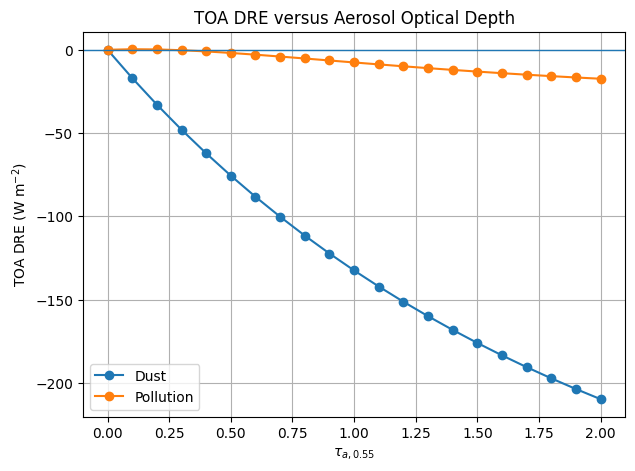

In [62]:
# Range of aerosol optical depths at 0.55 um
tau_a_055_values = np.linspace(0.0, 2.0, 21)

dust_TOA_DRE_values = []
poll_TOA_DRE_values = []

for tau_value in tau_a_055_values:

    # Scale spectral optical depth using normalized extinction coefficient
    tau_dust_test = tau_value * dust_Be
    tau_poll_test = tau_value * poll_Be

    # Run dust case
    dust_test = full_two_stream_model(
        tau_aer=tau_dust_test,
        omega_aer=dust_omega,
        g_aer=dust_g,
        case_name="dust"
    )

    # Run pollution case
    poll_test = full_two_stream_model(
        tau_aer=tau_poll_test,
        omega_aer=poll_omega,
        g_aer=poll_g,
        case_name="pollution"
    )

    # DRE relative to pristine
    dust_DRE_test = compute_DRE(dust_test, pristine)
    poll_DRE_test = compute_DRE(poll_test, pristine)

    # Store TOA DRE
    dust_TOA_DRE_values.append(dust_DRE_test["DRE_TOA"])
    poll_TOA_DRE_values.append(poll_DRE_test["DRE_TOA"])

dust_TOA_DRE_values = np.array(dust_TOA_DRE_values)
poll_TOA_DRE_values = np.array(poll_TOA_DRE_values)

# Estimate forcing efficiency using linear fit
dust_FE = np.polyfit(tau_a_055_values, dust_TOA_DRE_values, 1)[0]
poll_FE = np.polyfit(tau_a_055_values, poll_TOA_DRE_values, 1)[0]

print("Dust TOA forcing efficiency:", dust_FE, "W m^-2 per unit AOD")
print("Pollution TOA forcing efficiency:", poll_FE, "W m^-2 per unit AOD")

plt.figure(figsize=(7, 5))

plt.plot(tau_a_055_values, dust_TOA_DRE_values, marker="o", label="Dust")
plt.plot(tau_a_055_values, poll_TOA_DRE_values, marker="o", label="Pollution")

plt.axhline(0, linewidth=1)

plt.xlabel(r"$\tau_{a,0.55}$")
plt.ylabel("TOA DRE (W m$^{-2}$)")
plt.title("TOA DRE versus Aerosol Optical Depth")
plt.legend()
plt.grid(True)

plt.show()

Based on the plot above, the dust aerosol has a larger negative FE at TOA compared to pollution. Since dust has higher single scattering albedo, increasing the optical depth and adding more dust particles increases the chance of radiation scattering back into the space. While pollution also shows a negative FE at TOA, its magnitude is less than dust due to its stronger absorption feature. As a result, the dust layer FE is stronger than pollution.

# Part III: Student Investigation

My question is that in a 3-layered atmosphere with rayleigh scattering, dust, and pollution, how do the sequence of the layers affect the DRE at TOA, atmosphere, and surface? 
Hypothesis: The order of the layers in the atmosphere is the most important when it comes to the scene reflectance. If a layer with higher reflectance is above, the amount of radiation sent back to space increases and TOA DRE would have a cooling effect. For the atmosphere DRE, it would be a lower positive number when a more reflecting layer is on top. However, the order of the layers will not affect the surface DRE drastically, as it is a function of scene transmittance that is independent of layers' order.
To answer this question, I will create 3 scenarios:
1. dust, pollution, pristine
2. pollution, dust, pristine
3. pristine, dust, pollution

Below, I'll modify my original two stream model to incorporate three layers and perform the simulation:

In [65]:
def full_two_stream_model_3_layer(tau_dust, omega_dust, g_dust, tau_poll, omega_poll, g_poll):


    # Aerosol layer
    r_dust, t_dust = two_stream_atmospheric_layer(tau_dust, omega_dust, g_dust)
    r_poll, t_poll = two_stream_atmospheric_layer(tau_poll, omega_poll, g_poll)
    r_aer, t_aer = combine_two_atmospheric_layers(r_dust, t_dust, r_poll, t_poll)

    # Rayleigh layer
    r_ray, t_ray = two_stream_atmospheric_layer(tau_R, omega_R, g_R)

    # Combine aerosol layer over Rayleigh layer
    r_atm, t_atm = combine_two_atmospheric_layers(r_aer, t_aer, r_ray, t_ray)

    # Add ocean surface
    r_scene, t_scene = two_stream_model_with_surface(r_atm, t_atm, ocean_reflectance)

    # Compute spectral fluxes
    flux = compute_fluxes(r_scene, t_scene, ocean_reflectance, F0_i)

    result = {
        "case_name": "dust+pollution+pristine",
        "r_aer": r_aer,
        "t_aer": t_aer,
        "r_ray": r_ray,
        "t_ray": t_ray,
        "r_atm": r_atm,
        "t_atm": t_atm,
        "r_scene": r_scene,
        "t_scene": t_scene,
        "flux": flux,
    }

    return result

def full_two_stream_model_3_layer_pristine(tau_dust, omega_dust, g_dust, tau_poll, omega_poll, g_poll):

    # Rayleigh layer
    r_ray, t_ray = two_stream_atmospheric_layer(tau_R, omega_R, g_R)
    r_dust, t_dust = two_stream_atmospheric_layer(tau_dust, omega_dust, g_dust)
    r_aer, t_aer = combine_two_atmospheric_layers(r_ray, t_ray, r_dust, t_dust)
    # Aerosol layer
    r_poll, t_poll = two_stream_atmospheric_layer(tau_poll, omega_poll, g_poll)
   



    # Combine aerosol layer over Rayleigh layer
    r_atm, t_atm = combine_two_atmospheric_layers(r_aer, t_aer, r_poll, t_poll)

    # Add ocean surface
    r_scene, t_scene = two_stream_model_with_surface(r_atm, t_atm, ocean_reflectance)

    # Compute spectral fluxes
    flux = compute_fluxes(r_scene, t_scene, ocean_reflectance, F0_i)

    result = {
        "case_name": "dust+pollution+pristine",
        "r_aer": r_aer,
        "t_aer": t_aer,
        "r_ray": r_ray,
        "t_ray": t_ray,
        "r_atm": r_atm,
        "t_atm": t_atm,
        "r_scene": r_scene,
        "t_scene": t_scene,
        "flux": flux,
    }

    return result

pristine = run_pristine_case()

case_1 = full_two_stream_model_3_layer(
    tau_dust =  tau_dust,
    omega_dust=dust_omega,
    g_dust=dust_g,
    tau_poll=tau_poll,
    omega_poll=poll_omega,
    g_poll=poll_g
)

case_2 = full_two_stream_model_3_layer(
    tau_dust=tau_poll,
    omega_dust=poll_omega,
    g_dust=poll_g,
    tau_poll=tau_dust,
    omega_poll=dust_omega,
    g_poll=dust_g
)

case_3 = full_two_stream_model_3_layer_pristine(
    tau_dust=tau_dust,
    omega_dust=dust_omega,
    g_dust=dust_g,
    tau_poll=tau_poll,
    omega_poll=poll_omega,
    g_poll=poll_g
)
case_1_flux = broadband_flux_summary(case_1)
case_2_flux = broadband_flux_summary(case_2)
case_3_flux = broadband_flux_summary(case_3)

flux_table = pd.DataFrame(
    [case_1_flux, case_2_flux, case_3_flux],
    index=["Dust on top", "Pollution on top", "Pristine on top"]
)
display(flux_table)

case_1_DRE = compute_DRE(case_1, pristine)
case_2_DRE = compute_DRE(case_2, pristine)
case_3_DRE = compute_DRE(case_3, pristine)

DRE_table = pd.DataFrame(
    {
        "Dust on top": {
            "DRE_TOA": case_1_DRE["DRE_TOA"],
            "DRE_sfc": case_1_DRE["DRE_sfc"],
            "DRE_atm": case_1_DRE["DRE_atm"],
        },
        "Pollution on top": {
            "DRE_TOA": case_2_DRE["DRE_TOA"],
            "DRE_sfc": case_2_DRE["DRE_sfc"],
            "DRE_atm": case_2_DRE["DRE_atm"],
        },
        "Pristine on top": {
            "DRE_TOA": case_3_DRE["DRE_TOA"],
            "DRE_sfc": case_3_DRE["DRE_sfc"],
            "DRE_atm": case_3_DRE["DRE_atm"],
        },
    }
)

display(DRE_table)


C:\Users\ehsan\AppData\Local\Temp\ipykernel_43196\2110050226.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(y, wavelength)


,Fdown_TOA,Fup_TOA,Fnet_TOA,Fdown_sfc,Fup_sfc,Fnet_sfc,Fnet_atm
Dust on top,1239.322141,260.009246,979.312895,536.684582,21.154677,515.529905,463.782990
Pollution on top,1239.322141,166.309430,1073.012711,532.383176,20.698123,511.685053,561.327657
Pristine on top,1239.322141,285.616133,953.706008,537.624822,21.273118,516.351704,437.354304


C:\Users\ehsan\AppData\Local\Temp\ipykernel_43196\2110050226.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(y, wavelength)


,Dust on top,Pollution on top,Pristine on top
DRE_TOA,-142.582031,-48.882215,-168.188918
DRE_sfc,-597.483206,-601.328058,-596.661407
DRE_atm,454.901175,552.445843,428.472489


The table above proves my initial hypothesis. When the pristine layer is on top, we have the highest single scattering layer (0.95) close to the TOA. This will increase the scene reflectance, increase the magnitude of negative TOA DRE, and cool down the earth. The dust layer on top also has the same effect only smaller due to its lower omega.
However, when the pollution is on top, we have our most absorbing layer near the TOA, which is going to absorb both incoming and outgoing radiation more. As a result, the cooling effect is reduced compared to the previous scenarios. 
As hypothesized, the surface DRE would not change much across all the cases, as scene transmittance is not a function of layers' order.
In case of atmosphere DRE, we can see that when the pollution level is on top, we have a more positive DRE and a higher warming effect. This is again due to the lower single scattering albedo of pollution and higher absorption capacity that traps the SW radiation.

# AI Usage

AI: ChtGPT

Usage: 
1. For this particular homework, I did not use AI for coding main model since all the equations and calculations where already available in notes. However, I used AI to create dictionaries of my model outputs that are able of storing all the properties calculated into one variable with keys and corresponding values. For example, this is the prompt I used:
I want to save all my model parameters and outputs in a dictionary that could be used for creating tables and visualization.

2. Also, I used AI for all the plotting sections.